# import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble  import RandomForestRegressor 
from sklearn.metrics import r2_score
import pickle

# Load the Dataset

In [8]:
df = pd.read_csv(r"D:\used_phone.csv")
df.head(2)

,brand,model,ram_gb,storage_gb,condition,battery_health,age_years,original_price,resale_price
0,Samsung,Galaxy A55 5G,8,256,Like New,61,2,39999,17567
1,Oppo,OPPO A58 5G,6,128,Fair,69,1,13999,5216


In [9]:
df['brand'].unique()

array(['Samsung', 'Oppo', 'OnePlus', 'Redmi', 'Realme', 'Vivo',
       'Motorola', 'Apple', 'iQOO', 'Infinix'], dtype=object)

In [10]:
df['model'].unique()

array(['Galaxy A55 5G', 'OPPO A58 5G', 'OnePlus Nord N30 SE 5G',
       'POCO X5 Pro 5G', 'Realme Narzo 60x 5G', 'Vivo Y18',
       'Motorola G24', 'Realme Narzo 20', 'Realme 11x 5G',
       'Vivo X100 Pro 5G', 'OPPO A18', 'Motorola G73 5G',
       'Motorola Edge 50 Fusion', 'Galaxy Z Flip 5', 'iPhone 14 (256GB)',
       'iQOO Z9 5G', 'iPhone 15 Pro Max', 'iPhone 14 Pro', 'GT 20 Pro',
       'Motorola G32', 'iPhone 13 (256GB)', 'Hot 40i', 'Vivo V29 5G',
       'Galaxy M55 5G', 'OPPO Reno 11 Pro 5G', 'Motorola G14',
       'Galaxy A23 5G', 'Galaxy S24', 'OPPO A17k', 'Galaxy S23 FE',
       'Galaxy A14 5G', 'Galaxy A35 5G', 'OnePlus Nord CE 3 5G',
       'OPPO A77s', 'Note 40 Pro 5G', 'Galaxy M14 5G', 'OPPO A17',
       'iPhone 13 Mini', 'Realme C51', 'Galaxy S24+', 'OnePlus Nord 3 5G',
       'Xiaomi 14 Ultra', 'Redmi Note 13 Pro 5G', 'Motorola E13',
       'OPPO K10 5G', 'Realme Narzo 50', 'Realme Narzo 10',
       'iQOO Z7 Pro 5G', 'iQOO 12 5G', 'iPhone 14 Pro Max (1TB)',
       'iQOO

# Information of Data

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   brand           5000 non-null   object
 1   model           5000 non-null   object
 2   ram_gb          5000 non-null   int64 
 3   storage_gb      5000 non-null   int64 
 4   condition       5000 non-null   object
 5   battery_health  5000 non-null   int64 
 6   age_years       5000 non-null   int64 
 7   original_price  5000 non-null   int64 
 8   resale_price    5000 non-null   int64 
dtypes: int64(6), object(3)
memory usage: 351.7+ KB


# Check Null value

In [12]:
df.isnull().sum()

brand             0
model             0
ram_gb            0
storage_gb        0
condition         0
battery_health    0
age_years         0
original_price    0
resale_price      0
dtype: int64

# Check Shape of Data

In [13]:
df.shape

(5000, 9)

# Check Duplicate values

In [14]:
df.duplicated().sum()

99

# Drop Duplicates

In [15]:
df=df.drop_duplicates()
df=df.reset_index(drop=True)

# Check Duplicate agains 

In [16]:
df.duplicated().sum()

0

# Check shape of Data again

In [17]:
df.shape
df.head(1)

,brand,model,ram_gb,storage_gb,condition,battery_health,age_years,original_price,resale_price
0,Samsung,Galaxy A55 5G,8,256,Like New,61,2,39999,17567


# 1. Pre-processing

In [18]:
le_brand = LabelEncoder()
le_model = LabelEncoder()
le_condition = LabelEncoder()

In [19]:
df['brand'] = le_brand.fit_transform(df['brand'])
df['model'] = le_model.fit_transform(df['model'])
df['condition'] = le_condition.fit_transform(df['condition'])

# 2.Train-test-split

In [20]:
x = df.drop(columns='resale_price')
y = df['resale_price']

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

# 3.Model: RandomForest Regression

In [22]:
model = RandomForestRegressor()
model.fit(x_train, y_train)

RandomForestRegressor()

# 4.Accuracy of model

In [23]:
y_pred = model.predict(x_test)

In [24]:
print("Score of model:", r2_score(y_pred, y_test))

Score of model: 0.9865820776347859


# Correlation of heatmap

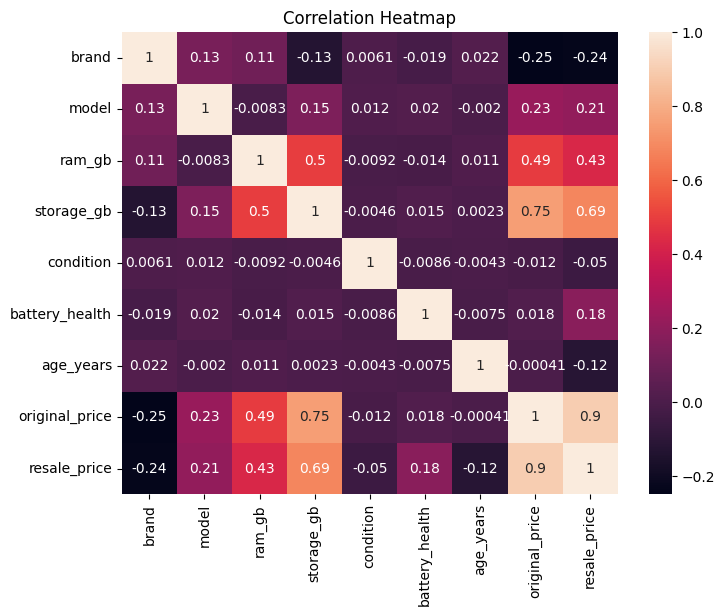

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Save the file

In [26]:
with open("phone_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!
